# Notebook: 10 Master Execution Plan
### Purpose: Complete pipeline from data preparation to final submission

In [2]:
import copy
import json
import os
import random
import sys
from datetime import datetime
from pathlib import Path

import cv2
import pandas as pd

from data.image_loader import validate_image_directory
from exploration.class_explorer import color_mask, load_image, mask_all
from models.zoo import MODEL_EXPERIMENTS
from src.exploration.visualize import show_side_by_side
from training.running import get_available_filters, validate_filter_set
from utils.helpers import format_time
from utils.image_converter import ImageConverter


#os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  #enable for debugging ONLY

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

import torch
from torch.utils.data import DataLoader
from src.data.annotations import load_json_annotations
from src.data.augmentations import get_train_augmentations, get_val_augmentations
from src.data.loaders import ImageMaskDataset
from src.training.engine import run_training
from src.utils.config import Config
from src.utils.helpers import c, init_notebook, p, t
from src.data.enhance_masks import EnhancedImageMaskDataset
from src.utils.versioning import VersionManager


config = Config.load()
#config = Config.load(Path("..").resolve() / "config_PROD.yaml")
init_notebook(config.train.seed)
config.show()





=== init_notebook ===
Done
=== Config settings ===
(removed C:\github\Tree-Canopy-Detection from paths)
Paths
  root: (root)
  train_images_zip: src\data\data1\train_images.zip
  train_images: src\data\data1\train_images
  train_masks: src\data\data1\train_masks
  eval_images_zip: src\data\data1\evaluation_images.zip
  eval_images: src\data\data1\evaluation_images
  eval_masks: src\data\data1\evaluation_masks
  data: data
  plots: plots
  annotations: src\data\data1\train_annotations.json
  notebooks: notebooks
  models: checkpoints
  checkpoint: None
  best_model: None
Train parameters
  image_size: 224
  batch_size: 8
  num_workers: 2
  epochs: 2
  learning_rate: 0.01
  early_stop_patience: 2
  scheduler_factor: 0.5
  scheduler_patience: 3
  seed: 42
  best_val_loss: 1000000000.0
Extra
  extra: {'log_predictions': True, 'use_amp': True}


#### Step 1: Data Preparation

- TIFF → PNG conversion (notebook 00_preprocess_images)
- Annotation loading
- Mask generation
- Data augmentation



In [3]:
t("Loading Annotations")
entries = load_json_annotations(config.paths.annotations)
p("Total images", len(entries))

if config.paths.eval_images and config.paths.eval_images.exists():
    # Check if conversion is needed
    tiff_files = list(config.paths.eval_images.glob("*.tif")) + list(config.paths.eval_images.glob("*.tiff"))
    png_files = list(config.paths.eval_images.glob("*.png"))

    p("TIFF files found", len(tiff_files), color1 = c.BLACK)
    p("PNG files found", len(png_files), color1 = c.BLACK)

    if len(tiff_files) > 0:
        p("Converting TIFF to PNG...", color1 = c.ORANGE)
        eval_converter = ImageConverter(
                source_dir = config.paths.eval_images,
                target_dir = config.paths.eval_images
        )
        eval_stats = eval_converter.convert_batch(overwrite = False)
        p("Converted", eval_stats.get("converted", 0), color1 = c.ORANGE)
        p("Skipped (already exist)", eval_stats.get("skipped", 0), color1 = c.ORANGE)
        p("Failed", eval_stats.get("failed", 0), color1 = c.ORANGE)
    else:
        p("No TIFF files to convert", color1 = c.GREEN)

    # Validate
    eval_validation = validate_image_directory(config.paths.eval_images)
    p("Valid images after conversion", eval_validation.get("valid", 0), color1 = c.BLACK)
else:
    p("Warning", "Eval images directory not found", color1 = c.ORANGE)

# Analyze class distribution
individual_count = sum(1 for e in entries if any(item.cls == "individual_tree" for item in e.items))
group_count = sum(1 for e in entries if any(item.cls == "group_of_trees" for item in e.items))

p("Images with individual trees", individual_count)
p("Images with tree groups", group_count)



=== Loading Annotations ===
Total images: 150
TIFF files found: 150
PNG files found: 150
Converting TIFF to PNG...
[Info]: Found 300 TIFF files


Converting TIFFs to PNG: 100%|██████████| 300/300 [00:00<00:00, 32686.28it/s]

=== Conversion Summary ===
[Info]: Total files: 300
[Info]: Converted: 0
[Info]: Skipped: 300
[Info]: Failed: 0
Converted: 0
Skipped (already exist): 300
Failed: 0
Validating images: 150 files


Valid images: 150
Invalid images: 0
Valid images after conversion: 150
Images with individual trees: 150
Images with tree groups: 119


#### Step 2: Filter Experimentation

**Action:** Run and retrieve notebook 08 to identify top 3 filters

**Expected Output:**
- Filter ranking CSV
- Top 3 filter names
- Visual comparisons



##### Validate Available Filters

In [4]:


# Get available filters
t("Validating Available Filters")
AVAILABLE_FILTERS = get_available_filters()
p("Available filters count", len(AVAILABLE_FILTERS))
p("Sample filters", AVAILABLE_FILTERS, show = 15, color1 = c.ORANGE)

=== Validating Available Filters ===
Available filters count: 49
Sample filters: 49 items
  0: bilateral
  1: box_blur_3x3
  2: box_blur_5x5
  3: canny
  4: clahe
  5: cv2_gaussian_3x3
  6: cv2_gaussian_5x5
  7: edge_enhance
  8: edge_enhance_strong
  9: emboss_1
  10: emboss_2
  11: gaussian_2x2_sigma1
  12: gaussian_2x2_sigma2
  13: gaussian_3x3
  14: gaussian_3x3_sigma1


#### Step 3: Enhanced Dataset Creation

- Create training dataset with filter-enhanced inputs
- Apply filters as additional channels.



In [5]:
t("Dataset modes")

val_transform = get_val_augmentations(config.train.image_size)
sample_entries = entries[:5]

# for mode in ['rgb', 'filtered', 'concat']:
for mode in ['rgb', 'filtered']:
    try:
        dataset = EnhancedImageMaskDataset(
                sample_entries,
                config.paths.train_images,
                mode = mode,
                transform = val_transform
        )

        img_t, mask_t = dataset[0]
        p(f"Mode {mode}", f"\n\tImage shape: {img_t.shape}, \n\tMask shape: {mask_t.shape}", color1 = c.ORANGE)
    except Exception as e:
        p(f"Mode: {mode}", f"FAILED: {e}", color1 = c.RED, color2 = c.RED)


=== Dataset modes ===
Mode rgb: 
	Image shape: torch.Size([3, 224, 224]), 
	Mask shape: torch.Size([224, 224])
Mode filtered: 
	Image shape: torch.Size([3, 224, 224]), 
	Mask shape: torch.Size([224, 224])


#### Step 4: Model Training Comparison

**Experiment Design:**
Comparing model performance across input types:
1. Baseline: RGB only
2. Filtered: Top 3 filters as channels
3. Concat: RGB + Filters (6 channels)

**Models to test:**
- SimpleCNN (fast baseline)
- UNet (standard architecture)
- SMP UNet + ResNet34 (transfer learning)



##### Experiment setup

In [6]:
t("Filter Sets")

# Define filter combinations to test
filter_sets = {
    'classic':        ['laplacian', 'sobel', 'clahe'],
    'gaussian':       ['gaussian_3x3', 'gaussian_5x5', 'gaussian_7x7'],
    'kernel_sharpen': ['sharpen_basic', 'high_pass_3x3', 'edge_enhance'],
    'kernel_edge':    ['sobel_x', 'sobel_y', 'laplacian_3x3'],
    'combined':       ['laplacian', 'gaussian_5x5', 'clahe'],
}

# Validate all filter sets before proceeding

all_valid = True

for set_name, filters in filter_sets.items():
    is_valid, invalid, suggestions = validate_filter_set(filters, AVAILABLE_FILTERS)

    if is_valid:
        p(f"Filter set '{set_name}'", "VALID", color1 = c.GREEN)
    else:
        p(f"Filter set '{set_name}'", f"INVALID: {invalid}", color1 = c.RED, color2 = c.RED)
        if suggestions:
            p("  Suggestions", suggestions, color1 = c.ORANGE)
        all_valid = False

if not all_valid:
    p("")
    p("WARNING", "Some filter sets have invalid filter names!", color1 = c.RED, color2 = c.RED)
    p("", "Check filter names against AVAILABLE_FILTERS", color1 = c.ORANGE)

p("")
p("filter_sets", filter_sets, color1 = c.ORANGE)

=== Filter Sets ===
Filter set 'classic': VALID
Filter set 'gaussian': VALID
Filter set 'kernel_sharpen': VALID
Filter set 'kernel_edge': VALID
Filter set 'combined': VALID

filter_sets: 5 keys
  classic: ['laplacian', 'sobel', 'clahe']
  gaussian: ['gaussian_3x3', 'gaussian_5x5', 'gaussian_7x7']
  kernel_sharpen: ['sharpen_basic', 'high_pass_3x3', 'edge_enhance']
  kernel_edge: ['sobel_x', 'sobel_y', 'laplacian_3x3']
  combined: ['laplacian', 'gaussian_5x5', 'clahe']


In [7]:

t("Available experiments")

all_experiments = MODEL_EXPERIMENTS(filter_sets)

# Concat mode: 6 channels (RGB + 3 filters)
# Note: This requires model architecture modification for 6-channel input

p("All experiments", all_experiments, show = 100, color1 = c.ORANGE)

=== Available experiments ===
All experiments: 84 items
  0: ('simple_cnn', 'rgb', None)
  1: ('simple_cnn', 'concat', None)
  2: ('simple_cnn', 'filtered', ['laplacian', 'sobel', 'clahe'])
  3: ('simple_cnn', 'filtered', ['gaussian_3x3', 'gaussian_5x5', 'gaussian_7x7'])
  4: ('simple_cnn', 'filtered', ['sharpen_basic', 'high_pass_3x3', 'edge_enhance'])
  5: ('simple_cnn', 'filtered', ['sobel_x', 'sobel_y', 'laplacian_3x3'])
  6: ('simple_cnn', 'filtered', ['laplacian', 'gaussian_5x5', 'clahe'])
  7: ('unet', 'rgb', None)
  8: ('unet', 'concat', None)
  9: ('unet', 'filtered', ['laplacian', 'sobel', 'clahe'])
  10: ('unet', 'filtered', ['gaussian_3x3', 'gaussian_5x5', 'gaussian_7x7'])
  11: ('unet', 'filtered', ['sharpen_basic', 'high_pass_3x3', 'edge_enhance'])
  12: ('unet', 'filtered', ['sobel_x', 'sobel_y', 'laplacian_3x3'])
  13: ('unet', 'filtered', ['laplacian', 'gaussian_5x5', 'clahe'])
  14: ('smp_unet', 'rgb', None)
  15: ('smp_unet', 'concat', None)
  16: ('smp_unet', 'filte

In [8]:
t("Setup experiments to run ")

experiments = [all_experiments[77]]
#experiments = all_experiments

p("Experiments to Run", experiments, show = 50, color1 = c.RED)


=== Setup experiments to run  ===
Experiments to Run: 84 items
  0: ('simple_cnn', 'rgb', None)
  1: ('simple_cnn', 'concat', None)
  2: ('simple_cnn', 'filtered', ['laplacian', 'sobel', 'clahe'])
  3: ('simple_cnn', 'filtered', ['gaussian_3x3', 'gaussian_5x5', 'gaussian_7x7'])
  4: ('simple_cnn', 'filtered', ['sharpen_basic', 'high_pass_3x3', 'edge_enhance'])
  5: ('simple_cnn', 'filtered', ['sobel_x', 'sobel_y', 'laplacian_3x3'])
  6: ('simple_cnn', 'filtered', ['laplacian', 'gaussian_5x5', 'clahe'])
  7: ('unet', 'rgb', None)
  8: ('unet', 'concat', None)
  9: ('unet', 'filtered', ['laplacian', 'sobel', 'clahe'])
  10: ('unet', 'filtered', ['gaussian_3x3', 'gaussian_5x5', 'gaussian_7x7'])
  11: ('unet', 'filtered', ['sharpen_basic', 'high_pass_3x3', 'edge_enhance'])
  12: ('unet', 'filtered', ['sobel_x', 'sobel_y', 'laplacian_3x3'])
  13: ('unet', 'filtered', ['laplacian', 'gaussian_5x5', 'clahe'])
  14: ('smp_unet', 'rgb', None)
  15: ('smp_unet', 'concat', None)
  16: ('smp_unet',

In [9]:




t("Runtime Estimate")


def estimate_runtime( experiments, filter_sets ):
    """
    Estimate training runtime using:
      - experiments list
      - filter_sets dict
    Adjusts time for rgb vs filtered vs concat.
    """

    train_size = int(0.8 * len(entries))
    batch_size = config.train.batch_size
    batches_per_epoch = max(1, train_size // batch_size)
    epochs = config.train.epochs

    # Baseline timing assumption (seconds per batch)
    base_seconds = 1.0

    total_seconds = 0.0

    p("Experiments", len(experiments), color1 = c.BLACK, color2 = c.ORANGE)
    p("Filter sets", len(filter_sets), color1 = c.BLACK, color2 = c.ORANGE)
    p("Number of Epochs", epochs, color1 = c.BLACK, color2 = c.ORANGE)

    # def count_params(model):
    #     return sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Mode timing multipliers
    mode_multiplier = { "rgb": 1.0, "filtered": 1.5, "concat": 2.0 }
    p("Models:", color1 = c.BLACK)
    for model_name, mode, filters in experiments:

        ## params = count_params(models[model_name])
        ## p(count_params(model_name))
        # base seconds per batch
        sec_per_batch = base_seconds * mode_multiplier.get(mode, 1.0)

        exp_seconds = epochs * batches_per_epoch * sec_per_batch
        total_seconds += exp_seconds

        p(f"\t{model_name} | {mode}", format_time(exp_seconds), color1 = c.BLUE)

    p()
    t("Totals")
    p("Training samples", train_size)
    p("Batches per epoch", batches_per_epoch)
    p("Estimated total time", f"~{format_time(total_seconds)}", color1 = c.BLACK, color2 = c.RED)


estimate_runtime(experiments, filter_sets)


=== Runtime Estimate ===
Experiments: 84
Filter sets: 5
Number of Epochs: 2
Models:
	simple_cnn | rgb: 30 sec
	simple_cnn | concat: 1 min
	simple_cnn | filtered: 45 sec
	simple_cnn | filtered: 45 sec
	simple_cnn | filtered: 45 sec
	simple_cnn | filtered: 45 sec
	simple_cnn | filtered: 45 sec
	unet | rgb: 30 sec
	unet | concat: 1 min
	unet | filtered: 45 sec
	unet | filtered: 45 sec
	unet | filtered: 45 sec
	unet | filtered: 45 sec
	unet | filtered: 45 sec
	smp_unet | rgb: 30 sec
	smp_unet | concat: 1 min
	smp_unet | filtered: 45 sec
	smp_unet | filtered: 45 sec
	smp_unet | filtered: 45 sec
	smp_unet | filtered: 45 sec
	smp_unet | filtered: 45 sec
	smp_fpn | rgb: 30 sec
	smp_fpn | concat: 1 min
	smp_fpn | filtered: 45 sec
	smp_fpn | filtered: 45 sec
	smp_fpn | filtered: 45 sec
	smp_fpn | filtered: 45 sec
	smp_fpn | filtered: 45 sec
	smp_linknet | rgb: 30 sec
	smp_linknet | concat: 1 min
	smp_linknet | filtered: 45 sec
	smp_linknet | filtered: 45 sec
	smp_linknet | filtered: 45 sec
	smp_

In [10]:
t("Train Experiments")

# Initialize best model tracker
best_model_tracker = {
    "best_val_loss":    float('inf'),
    "best_iou":         0.0,
    "best_experiment":  None,
    "best_model_path":  None,
    "best_version_dir": None,
}

# Running experiments
results = { }

for i, (model_name, mode, filters) in enumerate(experiments, 1):
    p("\n\n")
    t(f"Experiment {i}/{len(experiments)}")
    p("Model", model_name, color1 = c.ORANGE)
    p("Mode", mode, color1 = c.ORANGE)
    p("Filters", filters, color1 = c.ORANGE)

    # experiment key
    key = f"{model_name}_{mode}"
    if filters:
        filter_key = "_".join(filters)[:20]
        key = f"{key}_{filter_key}"
    p("key", key)

    try:
        # Prepare data
        train_entries = entries[: int(0.8 * len(entries))]
        val_entries = entries[int(0.8 * len(entries)):]

        train_tf = get_train_augmentations(config.train.image_size)
        val_tf = get_val_augmentations(config.train.image_size)

        train_ds = EnhancedImageMaskDataset(
                train_entries,
                config.paths.train_images,
                mode = mode,
                filter_names = filters,
                transform = train_tf,
        )
        val_ds = EnhancedImageMaskDataset(
                val_entries,
                config.paths.train_images,
                mode = mode,
                filter_names = filters,
                transform = val_tf,
        )
        # Determine input channels
        sample_img, _ = train_ds[0]
        in_channels = sample_img.shape[0]
        # Skip 6-channel experiments not supported yet
        if in_channels == 6 and model_name in ["simple_cnn", "unet"]:
            p("Warning", f"Skipping 6-channel experiment for {model_name}", color1 = c.ORANGE)
            continue

        train_loader = DataLoader(
                train_ds,
                batch_size = config.train.batch_size,
                shuffle = True,
                num_workers = config.train.num_workers,
                pin_memory = True if torch.cuda.is_available() else False,
        )

        val_loader = DataLoader(
                val_ds,
                batch_size = config.train.batch_size,
                shuffle = False,
                num_workers = config.train.num_workers,
                pin_memory = True if torch.cuda.is_available() else False,
        )

        version_root = config.paths.models / model_name / mode
        if filters:
            filter_str = "_".join(filters)
            version_root = version_root / filter_str[:30]
        version_root.mkdir(parents = True, exist_ok = True)
        p("Version root", version_root)

        # saving custom config
        exp_config = copy.deepcopy(config)
        exp_config.extra["experiment"] = {
            "model_name":     model_name,
            "input_mode":     mode,
            "filter_names":   filters,
            "input_channels": in_channels,
        }

        # Check if experiment already completed successfully
        best_model_path = version_root / "best_model.pth"
        checkpoint_path_check = version_root / "checkpoint.pth"

        if best_model_path.exists():
            p(f"SKIPPING {i}/{len(experiments)}", key, color1 = c.CYAN, color2 = c.CYAN)
            p("[Info]", f"Already trained: {best_model_path}", color1 = c.CYAN)

            # Still check if this is the best model overall
            if checkpoint_path_check.exists():
                try:
                    ckpt = torch.load(checkpoint_path_check, map_location = "cpu")
                    val_loss = ckpt.get("best_val_loss", float('inf'))
                    p("[Info]", f"Previous Val Loss: {val_loss:.6f}", color1 = c.CYAN)

                    if val_loss < best_model_tracker["best_val_loss"]:
                        best_model_tracker["best_val_loss"] = val_loss
                        best_model_tracker["best_experiment"] = key
                        best_model_tracker["best_model_path"] = best_model_path
                        best_model_tracker["best_version_dir"] = version_root
                        p("\t\t🏆 BEST MODEL (from previous run)", key, color1 = c.ORANGE, bold = True)
                except Exception as e:
                    p("Warning", f"Could not load checkpoint: {e}", color1 = c.ORANGE)

            continue

        trainer = run_training(
                config = exp_config,
                train_loader = train_loader,
                val_loader = val_loader,
                version_root = version_root,
                model_name = model_name,
        )

        if trainer is not None:
            results[key] = trainer

            # Check if this is the best model
            version_dir = trainer.version_dir
            checkpoint_path = version_dir / "checkpoint.pth"

            if checkpoint_path.exists():
                try:
                    ckpt = torch.load(checkpoint_path, map_location = "cpu")
                    val_loss = ckpt.get("best_val_loss", float('inf'))
                    p("[Info]", f"Val Loss: {val_loss:.6f}", color1 = c.GREEN)

                    if val_loss < best_model_tracker["best_val_loss"]:
                        best_model_tracker["best_val_loss"] = val_loss
                        best_model_tracker["best_experiment"] = key
                        best_model_tracker["best_model_path"] = version_dir / "best_model.pth"
                        best_model_tracker["best_version_dir"] = version_dir
                        p("\t\t🏆 NEW BEST MODEL", key, color1 = c.ORANGE, color2 = c.ORANGE, bold = True)

                except Exception as e:
                    p("Warning", f"Could not load checkpoint: {e}", color1 = c.ORANGE, color2 = c.ORANGE)

            p(f"COMPLETED {i}/{len(experiments)}", key, color1 = c.GREEN, color2 = c.GREEN)
        else:
            p(f"SKIPPED {i}/{len(experiments)}", key, color1 = c.ORANGE, color2 = c.ORANGE)

    except Exception as e:
        p(f"FAILED {i}/{len(experiments)}", key, color1 = c.RED, color2 = c.RED)
        p("[Error]", str(e), color1 = c.RED)
        results[key] = { "status": "ERROR", "error": str(e) }
        continue


=== Train Experiments ===



=== Experiment 1/84 ===
Model: simple_cnn
Mode: rgb
Filters
key: simple_cnn_rgb
Version root: C:\github\Tree-Canopy-Detection\checkpoints\simple_cnn\rgb
=== Training started ===
[Info]: GPU: NVIDIA GeForce MX350
[Info]: GPU Memory: 2.15 GB

[Warn]: Epoch 1


KeyboardInterrupt: 

In [ ]:

# Summary
t("Experiment Results Summary")
successful = sum(1 for v in results.values() if not isinstance(v, dict) or v.get("status") != "ERROR")
failed = sum(1 for v in results.values() if isinstance(v, dict) and "status" in v)
skipped = sum(1 for v in results.values() if v is None)

p("Total experiments", len(experiments))
p("Successful", successful - skipped, color1 = c.BLUE)
p("Skipped", skipped, color1 = c.ORANGE)
p("Failed", failed, color1 = c.RED if failed > 0 else c.RED)


##### Model Comparison & Best Model Selection

In [11]:
# List of metrics to extract
metrics_to_extract = [
    'best_val_loss',
    'epoch',
    'final_epoch',
    'train_loss',
    'val_loss',
    'val_accuracy',
    'val_iou',
    'iou',
    'accuracy',
    'f1_score',
    'precision',
    'recall',
]

In [12]:
# ### TO REMOVE
# #
# t("Collecting Experiment Results")
#
# experiment_results = []
#
# for i, (model_name, mode, filters) in enumerate(experiments, 1):
#     version_root = config.paths.models / model_name / mode
#
#     # If filters are specified, add filter subdirectory
#     if filters:
#         filter_str = "_".join(filters)[:30]
#         version_root = version_root / filter_str
#
#     if not version_root.exists():
#         p(f"No results found for {model_name} - {mode}", color1 = c.ORANGE)
#         continue
#
#     # Look for checkpoint
#     checkpoint_path = version_root / "checkpoint.pth"
#
#     versions = sorted(version_root.glob("v*"))
#
#     if not checkpoint_path.exists():
#         p(f"{i} No checkpoint found", f"{model_name} - {mode}", color1 = c.ORANGE)
#         continue
#
#     try:
#         # Load checkpoint to get metrics
#         ckpt = torch.load(checkpoint_path, map_location = "cpu")
#
#         # Prepare base metrics
#         experiment_result = {
#             'model':           model_name,
#             'mode':            mode,
#             'filters':         str(filters) if filters else 'none',
#             'checkpoint_path': str(checkpoint_path),
#             'version_path':    str(version_root),
#         }
#
#         # Extract metrics from checkpoint
#         for metric in metrics_to_extract:
#             # Try multiple ways of extracting the metric
#             value = (
#                     ckpt.get(metric) or  # Direct key
#                     (ckpt.get('metrics', { }).get(metric)) or  # Nested in 'metrics'
#                     None
#             )
#
#             # Only add non-None values
#             if value is not None:
#                 experiment_result[metric] = value
#
#         # Print extracted metrics for debugging
#         p(f"Metrics for {model_name} - {mode}:", color1 = c.CYAN)
#         for metric, value in experiment_result.items():
#             if metric not in ['model', 'mode', 'filters', 'checkpoint_path', 'version_path']:
#                 p(f"  {metric}: {value}", color1 = c.CYAN)
#
#         experiment_results.append(experiment_result)
#
#     except Exception as e:
#         p("Warning", f"Could not load {checkpoint_path}: {e}", color1 = c.ORANGE)
#         continue
#
# # Convert to DataFrame for easy analysis
# df_results = pd.DataFrame(experiment_results)
#
# if len(df_results) == 0:
#     p("No experiment results found", color1 = c.RED)
# else:
#     p("Total experiments found", len(df_results))
#
#     # Sort by validation loss (lower is better)
#     df_results = df_results.sort_values('best_val_loss')
#
#     p("")
#     p("Top 5 Experiments by Validation Loss", color1 = c.CYAN, bold = True)
#
#     display_columns = ['model', 'mode', 'filters', 'best_val_loss']
#
#     # Add additional columns that have non-None values
#     additional_cols = ['epoch', 'final_epoch', 'val_accuracy', 'f1_score', 'precision', 'recall', 'train_loss']
#
#     display_columns.extend([col for col in additional_cols if col in df_results.columns])
#
#     p(df_results[display_columns].head(10).to_string(index = False))
#
#     # Create a more detailed summary
#     p("\nDetailed Summary:", color1 = c.CYAN)
#
#     # Dynamically create aggregation dictionary
#     agg_dict = {
#         'best_val_loss': ['min', 'mean', 'count'],
#     }
#
#     # Add aggregations for additional metrics that are present
#     for col in additional_cols:
#         if col in df_results.columns:
#             agg_dict[col] = ['min', 'mean']
#
#     summary = df_results.groupby(['model', 'mode']).agg(agg_dict).reset_index()
#     p(summary.to_string(index = False))

In [13]:
t("Collecting Experiment Results")

experiment_results = []

# Iterate through all experiments
for i, (model_name, mode, filters) in enumerate(experiments, 1):
    p()
    p(f"Experiment {i}: {model_name}, {mode}, {filters}", color1 = c.MAGENTA, bold = True)

    # Construct version root path
    version_root = config.paths.models / model_name / mode

    # Add filter subdirectory if specified
    if filters:
        filter_str = "_".join(filters)[:30]
        version_root = version_root / filter_str

    p_version_root = str(version_root).replace(str(config.paths.root), "")
    p("Checking path", p_version_root, color1 = c.BLUE)

    # Check if directory exists
    if not version_root.exists():
        p(f"Directory does not exist: {p_version_root}", color1 = c.ORANGE)
        continue

    # Find ALL version subdirectories
    version_dirs = sorted(list(version_root.glob("v*")))

    if not version_dirs:
        p(f"No version directories found in {p_version_root}", color1 = c.ORANGE)
        continue

    # Use LATEST version
    latest_version_dir = version_dirs[-1]
    p(f"Found {len(version_dirs)} versions, using latest: {latest_version_dir.name}", color1 = c.GREEN)

    # Look for checkpoint files
    checkpoint_files = []
    for pattern in ["checkpoint.pth", "best_model.pth"]:
        found = list(latest_version_dir.glob(pattern))
        checkpoint_files.extend(found)

    if not checkpoint_files:
        p(f"No checkpoint files in {latest_version_dir.name}", color1 = c.ORANGE)
        continue

    # Prefer checkpoint.pth over best_model.pth
    checkpoint_files.sort(key = lambda x: 0 if x.name == "checkpoint.pth" else 1)
    checkpoint_path = checkpoint_files[0]

    p(f"Loading: {checkpoint_path.name}", color1 = c.CYAN)

    try:
        # Load checkpoint
        ckpt = torch.load(checkpoint_path, map_location = "cpu")

        # Extract metrics with fallbacks
        metrics_dict = { }

        for metric in metrics_to_extract:
            value = None

            # Try direct key
            if metric in ckpt:
                value = ckpt[metric]

            # Try nested in 'metrics'
            elif 'metrics' in ckpt and metric in ckpt['metrics']:
                value = ckpt['metrics'][metric]

            # Handle epoch/final_epoch aliases
            elif metric == 'final_epoch' and 'epoch' in ckpt:
                value = ckpt['epoch']
            elif metric == 'epoch' and 'final_epoch' in ckpt:
                value = ckpt['final_epoch']

            # Handle other aliases
            elif metric == 'iou' and 'val_iou' in ckpt:
                value = ckpt['val_iou']
            elif metric == 'accuracy' and 'val_accuracy' in ckpt:
                value = ckpt['val_accuracy']

            if value is not None:
                metrics_dict[metric] = value

        # Get filter string
        filters_str = str(filters) if filters else 'none'

        # Try to load config snapshot for extra info
        config_snapshot_path = latest_version_dir / "config_snapshot.json"
        additional_info = { }
        if config_snapshot_path.exists():
            try:
                with open(config_snapshot_path, 'r') as f:
                    snapshot = json.load(f)
                    additional_info = snapshot.get('config', { }).get('extra', { }).get('experiment', { })
            except Exception:
                pass

        # Build result entry
        result_entry = {
            'model':           model_name,
            'mode':            mode,
            'filters':         filters_str,
            'version':         latest_version_dir.name,
            'checkpoint_path': str(checkpoint_path),
            'version_path':    str(latest_version_dir),
            **additional_info,
            **metrics_dict
        }

        experiment_results.append(result_entry)

        p(f"✓ Loaded successfully - Metrics: {len(metrics_dict)}/{len(metrics_to_extract)}", color1 = c.GREEN)

        # Show missing metrics
        missing = [m for m in metrics_to_extract if m not in metrics_dict]
        if missing and len(missing) < 5:
            p(f"  Missing: {', '.join(missing)}", color1 = c.ORANGE)

    except Exception as e:
        p("ERROR loading checkpoint", str(e), color1 = c.RED)
        continue

# Convert to DataFrame
df_results = pd.DataFrame(experiment_results)

# %%
# Display results
p()
t("Results Summary")
p("Total experiments found", len(df_results))

if len(df_results) > 0:
    p("Available columns:", list(df_results.columns), show = 50, color1 = c.CYAN)

    # Select columns for display
    display_columns = ['model', 'mode', 'filters', 'version']
    for col in ['best_val_loss', 'final_epoch', 'val_accuracy', 'val_iou', 'iou']:
        if col in df_results.columns:
            display_columns.append(col)

    p("Displaying columns:", display_columns, color1 = c.CYAN)

    # Sort by best_val_loss if available
    sort_column = 'best_val_loss' if 'best_val_loss' in df_results.columns else display_columns[0]

    try:
        df_sorted = df_results.sort_values(by = sort_column, ascending = True)

        p()
        p("Top 10 Experiments", color1 = c.BLUE, bold = True)

        # Format display
        display_df = df_sorted[display_columns].head(10).copy()
        for col in display_df.columns:
            if display_df[col].dtype == float:
                display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else "N/A")

        print(display_df.to_string(index = False))

    except Exception as e:
        p(f"Error displaying results: {e}", color1 = c.RED)

else:
    p("No experiment results found!", color1 = c.RED, bold = True)

# %%
# Aggregation summary
agg_dict = { }
for col in metrics_to_extract:
    if col in df_results.columns:
        agg_dict[col] = ['min', 'mean', 'count']

if agg_dict and len(df_results) > 0:
    p()
    p("Detailed Summary:", color1 = c.BLUE, bold = True)

    summary = df_results.groupby(['model', 'mode']).agg(agg_dict).reset_index()
    summary.columns = [' '.join(col).strip() for col in summary.columns.values]

    # Format floats
    float_cols = [col for col in summary.columns if 'min' in col or 'mean' in col]
    for col in float_cols:
        summary[col] = summary[col].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else "N/A")

    try:
        summary = summary.sort_values('best_val_loss min', ascending = True)
    except:
        pass

    print(summary.to_string(index = False))
else:
    p("No aggregatable data", color1 = c.ORANGE)




=== Collecting Experiment Results ===

Experiment 1: simple_cnn, rgb, None
Checking path: \checkpoints\simple_cnn\rgb
Found 3 versions, using latest: v003
Loading: checkpoint.pth
✓ Loaded successfully - Metrics: 3/12

Experiment 2: simple_cnn, concat, None
Checking path: \checkpoints\simple_cnn\concat
Found 1 versions, using latest: v001
No checkpoint files in v001

Experiment 3: simple_cnn, filtered, ['laplacian', 'sobel', 'clahe']
Checking path: \checkpoints\simple_cnn\filtered\laplacian_sobel_clahe
Found 3 versions, using latest: v003
Loading: checkpoint.pth
✓ Loaded successfully - Metrics: 3/12

Experiment 4: simple_cnn, filtered, ['gaussian_3x3', 'gaussian_5x5', 'gaussian_7x7']
Checking path: \checkpoints\simple_cnn\filtered\gaussian_3x3_gaussian_5x5_gaus
Found 3 versions, using latest: v003
Loading: checkpoint.pth
✓ Loaded successfully - Metrics: 3/12

Experiment 5: simple_cnn, filtered, ['sharpen_basic', 'high_pass_3x3', 'edge_enhance']
Checking path: \checkpoints\simple_cnn\fil

In [14]:
# Convert to DataFrame for easy analysis
df_results = pd.DataFrame(experiment_results)

p("Total experiments found", len(df_results))

# Print available columns for debugging
p("Available columns:", list(df_results.columns), show = 50, color1 = c.RED)

# Dynamically select columns based on available metrics
display_columns = ['model', 'mode', 'filters']
additional_cols = metrics_to_extract

# Add additional columns that have non-None values
for col in additional_cols:
    if col in df_results.columns:
        display_columns.append(col)

p("Columns to display:", display_columns, color1 = c.CYAN)


Total experiments found: 66
Available columns:: 13 items
  0: model
  1: mode
  2: filters
  3: version
  4: checkpoint_path
  5: version_path
  6: model_name
  7: input_mode
  8: filter_names
  9: input_channels
  10: best_val_loss
  11: epoch
  12: final_epoch
Columns to display:: 6 items
  0: model
  1: mode
  2: filters
  3: best_val_loss
  4: epoch


In [15]:
# Check if we have any sortable columns
sort_column = 'best_val_loss' if 'best_val_loss' in df_results.columns else display_columns[0]

try:
    # Sort and select top 10 experiments
    sorted_results = df_results[display_columns].sort_values(
            by = sort_column, ascending = True
    )

    p("")
    p("Top 10 Experiments", color1 = c.BLUE, bold = True)

    # Format float columns to limit decimal places
    float_cols = [col for col in display_columns if df_results[col].dtype == float]
    for col in float_cols:
        sorted_results[col] = sorted_results[col].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else x)

    p(sorted_results.head(10).to_string(index = False), color1 = c.BLACK)

except Exception as e:
    p(f"Error sorting results: {e}", color1 = c.RED)
    p(sorted_results.head(10).to_string(index = False), color1 = c.BLACK)


Top 10 Experiments
            model     mode                                            filters best_val_loss  epoch  final_epoch
       simple_cnn filtered ['sharpen_basic', 'high_pass_3x3', 'edge_enhance']        0.5045      1            1
       simple_cnn      rgb                                               none        0.5162      1            1
      smp_linknet      rgb                                               none        0.5345      1            1
       simple_cnn filtered            ['sobel_x', 'sobel_y', 'laplacian_3x3']        0.5368      1            1
          yolov8l filtered                    ['laplacian', 'sobel', 'clahe']        0.5500      1            1
          yolov8n filtered ['sharpen_basic', 'high_pass_3x3', 'edge_enhance']        0.5544      1            1
smp_deeplabv3plus filtered             ['laplacian', 'gaussian_5x5', 'clahe']        0.5673      1            1
      smp_linknet filtered            ['sobel_x', 'sobel_y', 'laplacian_3x3']       

In [1]:
# Prepare aggregation dictionary dynamically
agg_dict = { }
for col in additional_cols:
    if col in df_results.columns:
        agg_dict[col] = ['min', 'mean', 'count']

if agg_dict:
    p("\nDetailed Summary:", color1 = c.BLUE, bold = True)

    # Create summary with dynamic columns
    summary = df_results.groupby(['model', 'mode']).agg(agg_dict).reset_index()

    # Flatten multi-level column names for readability
    summary.columns = [' '.join(col).strip() for col in summary.columns.values]

    # Format float columns to limit decimal places
    float_cols = [col for col in summary.columns if 'min' in col or 'mean' in col]
    for col in float_cols:
        summary[col] = summary[col].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else x)

    # Sort if possible
    try:
        summary = summary.sort_values('best_val_loss min', ascending = True)
    except:
        pass

    # p(summary.to_string(index = False), color1 = c.BLACK)
    summary
else:
    p("No aggregatable columns found", color1 = c.RED)

NameError: name 'additional_cols' is not defined

In [17]:

t("Best Model Selection")

if len(df_results) == 0:
    p("ERROR", "No experiments to compare", color1 = c.RED)
else:
    # Get best model (lowest validation loss)
    best_row = df_results.iloc[0]

    p("=" * 80, color1 = c.CYAN, bold = True)
    p("BEST MODEL", color1 = c.GREEN, bold = True)
    p("=" * 80, color1 = c.CYAN, bold = True)
    p("")
    p("Model", best_row['model'], color1 = c.GREEN)
    p("Input Mode", best_row['mode'], color1 = c.GREEN)
    p("Filters", best_row['filters'], color1 = c.GREEN)
    p("Best Val Loss", f"{best_row['best_val_loss']:.6f}", color1 = c.GREEN)
    p("Final Epoch", best_row['final_epoch'], color1 = c.GREEN)
    # Extract version from version_path if 'version' is not present
    version = best_row.get('version', Path(best_row['version_path']).name)
    p("Version", version, color1 = c.GREEN)

    p("Path", best_row['version_path'], color1 = c.BLUE)
    p("")

    # Check if this is better than previous best
    previous_best_path = config.paths.models / "BEST_MODEL.txt"

    is_new_best = False
    improvement = None

    if previous_best_path.exists():
        with open(previous_best_path, 'r') as f:
            lines = f.readlines()
            prev_loss = None
            for line in lines:
                if "best_val_loss:" in line:
                    try:
                        prev_loss = float(line.split(':')[1].strip())
                        break
                    except:
                        pass

        if prev_loss is not None:
            improvement = prev_loss - best_row['best_val_loss']

            if best_row['best_val_loss'] < prev_loss:
                is_new_best = True
                p("IMPROVEMENT", f"{improvement:.6f} (lower is better)", color1 = c.GREEN, bold = True)
            else:
                p("NO IMPROVEMENT", f"Previous best was {prev_loss:.6f}", color1 = c.ORANGE)
    else:
        is_new_best = True
        p("FIRST RUN", "No previous best to compare", color1 = c.CYAN)

    # Save new best model info
    if is_new_best:
        with open(previous_best_path, 'w') as f:
            f.write(f"model: {best_row['model']}\n")
            f.write(f"mode: {best_row['mode']}\n")
            f.write(f"filters: {best_row['filters']}\n")
            f.write(f"best_val_loss: {best_row['best_val_loss']}\n")
            f.write(f"epoch: {best_row['final_epoch']}\n")
            f.write(f"version: {best_row['version']}\n")
            f.write(f"path: {best_row['version_path']}\n")
            f.write(f"timestamp: {datetime.now().isoformat()}\n")

        p("")
        p("✓ Saved new best model info", str(previous_best_path), color1 = c.GREEN)

        # Copy best model to top-level for easy access
        best_model_src = Path(best_row['version_path']) / "best_model.pth"
        best_model_dst = config.paths.models / "BEST_MODEL.pth"

        if best_model_src.exists():
            import shutil


            shutil.copy2(best_model_src, best_model_dst)
            p("✓ Copied best model", str(best_model_dst), color1 = c.GREEN)

=== Best Model Selection ===
BEST MODEL

Model: simple_cnn
Input Mode: rgb
Filters: none
Best Val Loss: 0.516216
Final Epoch: 1
Version: v003
Path: C:\github\Tree-Canopy-Detection\checkpoints\simple_cnn\rgb\v003

NO IMPROVEMENT: Previous best was 0.516216


=== Performance Comparison Visualization ===
✓ Saved comparison plot: C:\github\Tree-Canopy-Detection\checkpoints\experiment_comparison.png


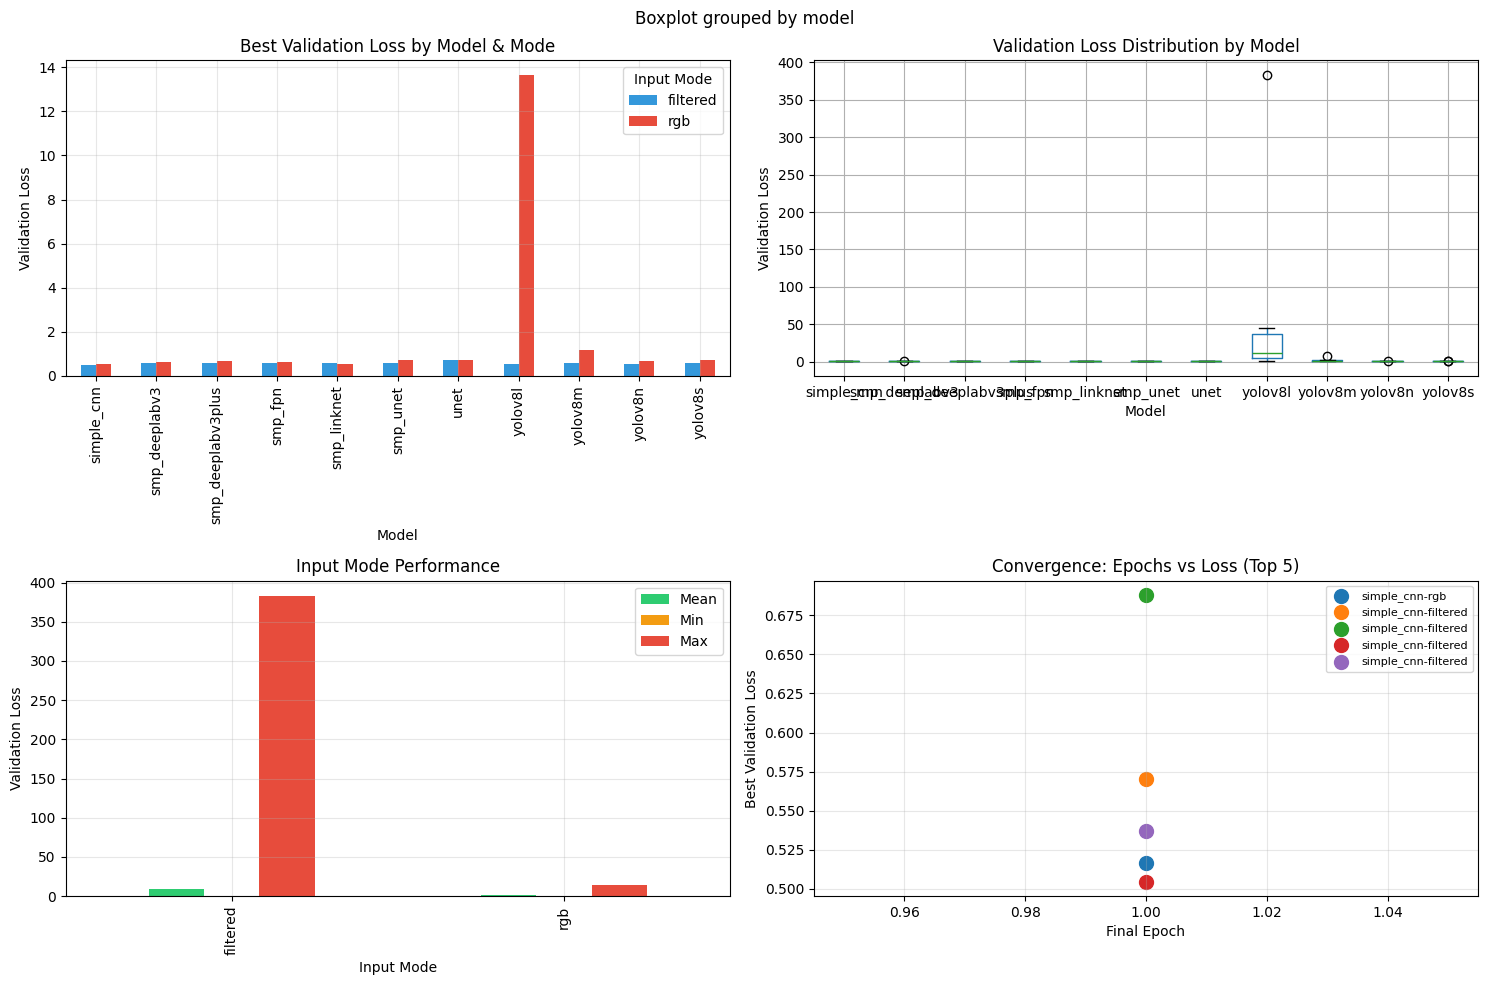

In [18]:
t("Performance Comparison Visualization")

if len(df_results) > 0:
    import matplotlib.pyplot as plt


    # Create comparison plots
    fig, axes = plt.subplots(2, 2, figsize = (15, 10))
    fig.suptitle('Model Performance Comparison', fontsize = 16, fontweight = 'bold')

    # Plot 1: Validation Loss by Model
    ax1 = axes[0, 0]
    df_pivot = df_results.pivot_table(values = 'best_val_loss', index = 'model', columns = 'mode', aggfunc = 'min')
    df_pivot.plot(kind = 'bar', ax = ax1, color = ['#3498db', '#e74c3c'])
    ax1.set_title('Best Validation Loss by Model & Mode')
    ax1.set_ylabel('Validation Loss')
    ax1.set_xlabel('Model')
    ax1.legend(title = 'Input Mode')
    ax1.grid(True, alpha = 0.3)

    # Plot 2: Loss Distribution
    ax2 = axes[0, 1]
    df_results.boxplot(column = 'best_val_loss', by = 'model', ax = ax2)
    ax2.set_title('Validation Loss Distribution by Model')
    ax2.set_ylabel('Validation Loss')
    ax2.set_xlabel('Model')
    plt.sca(ax2)
    plt.xticks(rotation = 0)

    # Plot 3: Mode Comparison
    ax3 = axes[1, 0]
    mode_stats = df_results.groupby('mode')['best_val_loss'].agg(['mean', 'min', 'max'])
    mode_stats.plot(kind = 'bar', ax = ax3, color = ['#2ecc71', '#f39c12', '#e74c3c'])
    ax3.set_title('Input Mode Performance')
    ax3.set_ylabel('Validation Loss')
    ax3.set_xlabel('Input Mode')
    ax3.legend(['Mean', 'Min', 'Max'])
    ax3.grid(True, alpha = 0.3)

    # Plot 4: Convergence Speed
    ax4 = axes[1, 1]
    for _, row in df_results.head(5).iterrows():
        label = f"{row['model']}-{row['mode']}"
        ax4.scatter(row['final_epoch'], row['best_val_loss'], s = 100, label = label)

    ax4.set_title('Convergence: Epochs vs Loss (Top 5)')
    ax4.set_xlabel('Final Epoch')
    ax4.set_ylabel('Best Validation Loss')
    ax4.legend(fontsize = 8)
    ax4.grid(True, alpha = 0.3)

    plt.tight_layout()

    # Save figure
    plot_path = config.paths.models / "experiment_comparison.png"
    plt.savefig(plot_path, dpi = 150, bbox_inches = 'tight')
    p("✓ Saved comparison plot", str(plot_path), color1 = c.GREEN)

    plt.show()

In [19]:
t("Exporting Results")

if len(df_results) > 0:
    # Save full results
    csv_path = config.paths.models / "all_experiments.csv"
    df_results.to_csv(csv_path, index = False)
    p("✓ Saved experiment results", str(csv_path), color1 = c.GREEN)

    # Create summary report
    summary_path = config.paths.models / "EXPERIMENT_SUMMARY.txt"

    with open(summary_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("EXPERIMENT SUMMARY\n")
        f.write("=" * 80 + "\n\n")

        f.write(f"Total experiments: {len(df_results)}\n")
        f.write(f"Timestamp: {datetime.now().isoformat()}\n\n")

        f.write("BEST MODEL:\n")
        best = df_results.iloc[0]
        f.write(f"  Model: {best['model']}\n")
        f.write(f"  Mode: {best['mode']}\n")
        f.write(f"  Filters: {best['filters']}\n")
        f.write(f"  Best Val Loss: {best['best_val_loss']:.6f}\n")
        f.write(f"  Path: {best['version_path']}\n\n")

        f.write("TOP 5 MODELS:\n")
        f.write("-" * 80 + "\n")
        for idx, row in df_results.head(5).iterrows():
            f.write(f"{idx + 1}. {row['model']} ({row['mode']}) - Loss: {row['best_val_loss']:.6f}\n")
            f.write(f"   Filters: {row['filters']}\n")
            f.write(f"   Path: {row['version_path']}\n\n")

        f.write("\nSTATISTICS BY MODEL:\n")
        f.write("-" * 80 + "\n")
        model_stats = df_results.groupby('model')['best_val_loss'].agg(['count', 'mean', 'min', 'max'])
        f.write(model_stats.to_string())
        f.write("\n\n")

        f.write("STATISTICS BY MODE:\n")
        f.write("-" * 80 + "\n")
        mode_stats = df_results.groupby('mode')['best_val_loss'].agg(['count', 'mean', 'min', 'max'])
        f.write(mode_stats.to_string())

    p("✓ Saved summary report", str(summary_path), color1 = c.GREEN)

    p("")
    p("=" * 80, color1 = c.CYAN, bold = True)
    p("EXPERIMENT COMPARISON COMPLETE", color1 = c.GREEN, bold = True)
    p("=" * 80, color1 = c.CYAN, bold = True)


=== Exporting Results ===
✓ Saved experiment results: C:\github\Tree-Canopy-Detection\checkpoints\all_experiments.csv
✓ Saved summary report: C:\github\Tree-Canopy-Detection\checkpoints\EXPERIMENT_SUMMARY.txt

EXPERIMENT COMPARISON COMPLETE


#### Step 5: Class-Specific Training

**Strategy:**
Trainning separate models for:
1. Individual trees
2. Groups of trees
3. Combined predictions

**Rationale:**
- Individual trees have distinct boundaries
- Tree groups have larger, more diffuse edges
- Specialized models may perform better



In [20]:
def train_class_specific_model( class_name, model_name = 'simple_cnn' ):
    """
    Train a model for a specific class.
    """
    t(f"Training {model_name} for class: {class_name}")

    # Filter entries by class
    class_entries = [
        e for e in entries
        if any(item.cls == class_name for item in e.items)
    ]

    p(f"Images with {class_name}", len(class_entries))

    if len(class_entries) < 10:
        p("Warning", "Insufficient samples for training", color1 = c.ORANGE)
        return None

    # Split
    split_idx = int(0.8 * len(class_entries))
    train_entries = class_entries[:split_idx]
    val_entries = class_entries[split_idx:]

    # Create datasets with class filter
    train_tf = get_train_augmentations(config.train.image_size)
    val_tf = get_val_augmentations(config.train.image_size)

    train_ds = ImageMaskDataset(
            train_entries,
            config.paths.train_images,
            classes = [class_name],
            transform = train_tf
    )

    val_ds = ImageMaskDataset(
            val_entries,
            config.paths.train_images,
            classes = [class_name],
            transform = val_tf
    )

    train_loader = DataLoader(
            train_ds,
            batch_size = config.train.batch_size,
            shuffle = True,
            num_workers = config.train.num_workers
    )

    val_loader = DataLoader(
            val_ds,
            batch_size = config.train.batch_size,
            shuffle = False,
            num_workers = config.train.num_workers
    )

    # Train using config epochs
    trainer = run_training(
            config = config,
            train_loader = train_loader,
            val_loader = val_loader,
            version_root = config.paths.models,
            model_name = model_name
    )

    return trainer


p("", "Class-specific training configured")

Class-specific training configured


In [21]:
# ## Train individual tree model
# try:
#     trainer_individual = train_class_specific_model('individual_tree', 'simple_cnn')
# except Exception as e:
#     p("Failed to train individual_tree model", str(e), color1=c.RED)
#     trainer_individual = None
#
# try:
#     trainer_group = train_class_specific_model('group_of_trees', 'simple_cnn')
# except Exception as e:
#     p("Failed to train group_of_trees model", str(e), color1=c.RED)
#     trainer_group = None

#### Step 6: Ensemble Predictions

**Approach:**
Combine predictions from multiple models:
1. RGB-trained model
2. Filter-enhanced model
3. Class-specific models

**Fusion methods:**
- Average (simple)
- Weighted average (based on validation IoU)
- Majority voting (threshold-based)



In [22]:
def ensemble_predict( models_and_weights, image_tensor, device = 'cpu' ):
    """
    Combine predictions from multiple models.
    """
    predictions = []
    total_weight = sum(w for _, w in models_and_weights)

    for model, weight in models_and_weights:
        model = model.to(device).eval()
        with torch.no_grad():
            pred = torch.sigmoid(model(image_tensor.to(device)))
        predictions.append(pred.cpu() * weight)

    # Weighted average
    avg_pred = sum(predictions) / total_weight
    return avg_pred


p("", "Ensemble prediction function ready")



Ensemble prediction function ready


#### Step 7: Submission Generation

**Current Status:**
- Prediction pipeline exists (notebook 05)
- Submission export implemented (`export_submission`)


In [23]:
p("eval_images", config.paths.eval_images)

eval_images: C:\github\Tree-Canopy-Detection\src\data\data1\evaluation_images


In [24]:
from src.prediction.pipeline import Predictor
from src.prediction.submission import export_submission


def generate_submission( model_path, model_name, eval_dir, output_path ):
    """
    Generate final submission JSON.
    """
    t("Generating Submission")

    # Initialize predictor
    predictor = Predictor(
            model_path = model_path,
            model_name = model_name,
            image_size = config.train.image_size
    )

    # Run predictions
    val_tf = get_val_augmentations(config.train.image_size)

    results = predictor.run_on_folder(eval_dir, transform = val_tf)

    p("Predictions generated", len(results))

    # Export submission
    export_submission(results, output_path)
    p("Submission saved", output_path)

    with open(output_path, 'r') as f:
        data = json.load(f)

    p("Images in submission", len(data.get('images', [])))

    # Check first entry structure
    if data.get('images'):
        first_img = data['images'][0]
        p("Sample entry keys", list(first_img.keys()), show = 15)
        if first_img.get('annotations'):
            first_ann = first_img['annotations'][0]
            p("Sample annotation keys", list(first_ann.keys()))

    return output_path

In [25]:

t("Generating Final Submission with Best Model")

# Load best model info
best_model_info_path = config.paths.models / "BEST_MODEL.txt"

if best_model_info_path.exists():
    with open(best_model_info_path, 'r') as f:
        lines = f.readlines()
        best_model_name = None
        best_model_path = None

        for line in lines:
            if "model:" in line:
                best_model_name = line.split(':')[1].strip()
            elif "path:" in line:
                best_model_path = Path(line.split(':', 1)[1].strip())

        if best_model_path and best_model_name:
            model_weights = best_model_path / "best_model.pth"

            p("Using best model", best_model_name, color1 = c.GREEN)
            p("From", str(best_model_path), color1 = c.BLUE)

            # from datetime import datetime
            # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

            # Generate submission
            #output_file = config.paths.models / f"FINAL_SUBMISSION_{timestamp}.json"
            output_file = config.paths.models / "FINAL_SUBMISSION.json"

            generate_submission(
                    model_path = model_weights,
                    model_name = best_model_name,
                    eval_dir = config.paths.eval_images,
                    output_path = output_file
            )

            p("✓ Final submission generated", str(output_file), color1 = c.GREEN, bold = True)
else:
    p("Warning", "No best model info found, skipping final submission", color1 = c.ORANGE)

=== Generating Final Submission with Best Model ===
Using best model: simple_cnn
From: C:\github\Tree-Canopy-Detection\checkpoints\simple_cnn\rgb\v003
=== Generating Submission ===
[Info]: Loaded model weights from C:\github\Tree-Canopy-Detection\checkpoints\simple_cnn\rgb\v003\best_model.pth
Predictions generated: 150
=== Submission Export Complete ===
✓ Submission saved: C:\github\Tree-Canopy-Detection\checkpoints\FINAL_SUBMISSION.json
✓ Total images: 150
✓ Total annotations: 1
✓ individual_tree annotations: 1
✓ group_of_trees annotations: 0
Submission saved: C:\github\Tree-Canopy-Detection\checkpoints\FINAL_SUBMISSION.json
Images in submission: 150
Sample entry keys: 6 items
  0: file_name
  1: width
  2: height
  3: cm_resolution
  4: scene_type
  5: annotations
✓ Final submission generated: C:\github\Tree-Canopy-Detection\checkpoints\FINAL_SUBMISSION.json


#### Generate submissions for all trained experiments

In [26]:
best_submissions = []

for model_name in all_model_names:
    for input_mode in all_input_modes:

        base_path = config.paths.models / model_name / input_mode

        if not base_path.exists():
            continue

        # Check for direct versions (no filter subdirectory)
        # e.g., models/simple_cnn/rgb/v001/
        vm = VersionManager(base_path)
        latest_version = vm.find_latest()

        if latest_version is not None:
            model_path = latest_version / "best_model.pth"
            if model_path.exists():
                output_file = latest_version / "submission.json"

                t(f"eval_images path: {config.paths.eval_images}")

                p("\nGenerating submission", f"{model_name}/{input_mode}", color1 = c.MAGENTA)

                try:
                    generate_submission(
                            model_path = model_path,
                            model_name = model_name,
                            eval_dir = config.paths.eval_images,
                            output_path = output_file
                    )

                    best_submissions.append(
                            {
                                "model":      model_name,
                                "mode":       input_mode,
                                "filters":    None,
                                "version":    str(latest_version),
                                "submission": str(output_file)
                            }
                    )
                    p("Saved submission", output_file)

                except Exception as e:
                    p("Failed", str(e), color1 = c.RED)

        # Check for filter subdirectories (for 'filtered' mode)
        # e.g., models/simple_cnn/filtered/laplacian_sobel_clahe/v001/
        if input_mode == 'filtered':
            for filter_subdir in base_path.iterdir():
                if not filter_subdir.is_dir():
                    continue
                if filter_subdir.name.startswith('v'):  # Skip version dirs
                    continue

                vm_filter = VersionManager(filter_subdir)
                latest_filter_version = vm_filter.find_latest()

                if latest_filter_version is None:
                    continue

                model_path = latest_filter_version / "best_model.pth"
                if not model_path.exists():
                    continue

                output_file = latest_filter_version / "submission.json"
                filter_name = filter_subdir.name

                p("\nGenerating submission", f"{model_name}/{input_mode}/{filter_name}", color1 = c.MAGENTA)

                try:
                    generate_submission(
                            model_path = model_path,
                            model_name = model_name,
                            eval_dir = config.paths.eval_images,
                            output_path = output_file
                    )

                    best_submissions.append(
                            {
                                "model":      model_name,
                                "mode":       input_mode,
                                "filters":    filter_name,
                                "version":    str(latest_filter_version),
                                "submission": str(output_file)
                            }
                    )
                    p("Saved submission", output_file)

                except Exception as e:
                    p("Failed", str(e), color1 = c.RED)

p("")
t("Submission Generation Complete")
p("Total submissions generated", len(best_submissions))

NameError: name 'all_model_names' is not defined

In [ ]:
# Build global list of all best experiment submissions
best_overall = None

for item in best_submissions:
    ckpt_path = Path(item["version"]) / "checkpoint.pth"

    if not ckpt_path.exists():
        continue

    try:
        ckpt = torch.load(ckpt_path, map_location = "cpu")
        val_loss = ckpt.get("best_val_loss", None)
        if val_loss is None:
            continue

        if best_overall is None or val_loss < best_overall["best_val_loss"]:
            best_overall = {
                "model":         item["model"],
                "mode":          item["mode"],
                "version":       item["version"],
                "submission":    item["submission"],
                "best_val_loss": val_loss
            }
    except Exception as e:
        p("Warning", f"Could not load checkpoint {ckpt_path}: {e}", color1 = c.ORANGE)
        continue

#Append overall best
if best_overall:
    best_submissions.append(
            {
                "model":         best_overall["model"],
                "mode":          best_overall["mode"],
                "version":       best_overall["version"],
                "submission":    best_overall["submission"],
                "best_val_loss": best_overall["best_val_loss"],
                "overall_best":  True
            }
    )

# ===== Summary =====
t("Best Submissions Summary")

for item in best_submissions:
    is_overall = item.get("overall_best", False)
    label = "\nOVERALL BEST" if is_overall else "\nExperiment"

    p(label, f"{item['model']} | {item['mode']}", color1 = c.MAGENTA)
    p("Version", item["version"])
    p("Submission", item["submission"])

    if "best_val_loss" in item:
        p("Val Loss", item["best_val_loss"])
    p("")



In [ ]:

t("Visualizing Training Data (Ground Truth)")

image_dir = config.paths.train_images
p("Train images dir", image_dir)

# sample three entries
sample_entries = random.sample(entries, 5)

for e in sample_entries:
    p("Image", e.image_path.name)

    try:
        img = load_image(image_dir, e)
        mask = mask_all(e)
        mask_rgb = color_mask(e)
        overlay = cv2.addWeighted(img, 0.6, mask_rgb, 0.4, 0)

        show_side_by_side(
                img, mask, mask_rgb, overlay,
                titles = ("Original", "Mask", "Color Mask", "Overlay"),
                maxcolumns = 4
        )
    except Exception as e_viz:
        p("Failed to visualize", str(e_viz), color1 = c.ORANGE)


In [ ]:
t("Visualizing sample predictions")

image_dir = config.paths.eval_images
t(image_dir)

try:
    # Use the best model that was selected earlier
    predictor = Predictor(
            model_path = model_weights,
            model_name = best_model_name,
            image_size = config.train.image_size,
    )

    val_tf = get_val_augmentations(config.train.image_size)

    # Run prediction on a small subset of eval images
    results = predictor.run_on_folder(
            image_dir,
            transform = val_tf,
            num_samples = 5,
    )

    for r in results:
        name = r["name"]
        img = r["image"]
        pred_mask = r["mask"]
        overlay = r["overlay"]

        p("Eval image", name)

        show_side_by_side(
                img, pred_mask, overlay,
                titles = ("Original", "Pred mask", "Overlay"),
                maxcolumns = 3,
        )


except Exception as e_viz:
    p("Failed to visualize predictions", str(e_viz), color1 = c.ORANGE)

In [ ]:
import numpy as np


t("Visualizing predictions from submission")

submission_path = config.paths.models / "FINAL_SUBMISSION.json"
p("Submission file", submission_path)

try:
    with open(submission_path, "r", encoding = "utf8") as f:
        data = json.load(f)

    images = data.get("images", [])
    if not images:
        p("No images found in submission", color1 = c.ORANGE)
    else:
        num_samples = min(5, len(images))
        sample_entries = random.sample(images, num_samples)

        for entry in sample_entries:
            fname = entry["file_name"]
            img_path = config.paths.eval_images / fname

            # Optional: fallback to .png if only converted files exist
            if not img_path.exists():
                alt_png = img_path.with_suffix(".png")
                if alt_png.exists():
                    img_path = alt_png

            p("Eval image from submission", fname)

            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                p("Could not read image", str(img_path), color1 = c.ORANGE)
                continue

            img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            h = entry.get("height", img.shape[0])
            w = entry.get("width", img.shape[1])
            mask = np.zeros((h, w), dtype = np.uint8)

            # Rebuild multi class mask from polygons
            for ann in entry.get("annotations", []):
                seg = ann.get("segmentation", [])
                if not seg:
                    continue

                pts = np.array(seg, dtype = np.float32).reshape(-1, 2)
                pts = np.round(pts).astype(np.int32)
                cls = ann.get("class", "individual_tree")

                if cls == "individual_tree":
                    class_id = 1
                elif cls == "group_of_trees":
                    class_id = 2
                else:
                    class_id = 1

                cv2.fillPoly(mask, [pts], color = class_id)

            # Simple color mask for display
            mask_rgb = np.zeros_like(img)
            mask_rgb[mask == 1] = (0, 255, 0)  # individual trees
            mask_rgb[mask == 2] = (255, 255, 0)  # groups

            overlay = cv2.addWeighted(img, 0.6, mask_rgb, 0.4, 0)

            show_side_by_side(
                    img, mask, mask_rgb, overlay,
                    titles = ("Original", "Pred mask (ids)", "Color mask", "Overlay"),
                    maxcolumns = 4,
            )

except Exception as e_viz:
    p("Failed to visualize submission predictions", str(e_viz), color1 = c.ORANGE)
